# K means

Scrivere un algoritmo complesso ottimizzandolo per l'esecuzione in parallelo su una macchina a multi-core.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
from dataclasses import dataclass # for clear outputs in the form of a class

@dataclass
class KMeansResult:
    assignments: np.ndarray
    final_centroids: np.ndarray
    loss: list

In [2]:
from sklearn.datasets import fetch_rcv1, fetch_kddcup99, load_iris

In [3]:
data_pandas = load_iris(as_frame = True)
data_pandas.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
data_numpy = load_iris()

# Step 1: a serial version of kmeans

### Naive k-means with random initialization - first attempt

I implement the non-parallel version first, then the parallel version using python multiprocessing library.

In [5]:
class KMeansResult:
    def __init__(self, assignments, final_centroids, loss):
        self.assignments = assignments
        self.final_centroids = final_centroids
        self.loss = loss

def serial_k_means(k: int, X: np.ndarray, n_iter_max: int, seed: int, verbose = False):
    """
    Most basic version of k means, with random centroid initialization (Forgy).
    k: number of clusters
    X: data matrix with nrows = number of points, ncols = number of features
    n_max: maximum number of iterations

    The algorithm stops when either the assignations of the points do not change anymore,
    or n_max is reached.
    """
    # Global variables
    np.random.seed(seed)
    num_points = X.shape[0]
    D = X.shape[1]
    # Centroids initialization
    WCSD_list = [] # Within Cluster Square Distance
    idxs = np.random.choice(np.arange(0, num_points), size = k, replace = False)
    centroids = np.vstack(tup = [X[idx, :] for idx in idxs])
    distances = np.zeros(shape = (num_points, k)) # (i,j) contains distance of point i from centroid j
    assignments = np.zeros(shape = (num_points, ), dtype = int)
    # Iterative steps
    for n in range(n_iter_max):
        old_assignments = assignments.copy()
        # Assign points
        for point_idx in range(num_points):
            for cluster_idx in range(k):
                distances[point_idx, cluster_idx] = np.linalg.norm(X[point_idx, :] - centroids[cluster_idx, :])
            assignments[point_idx] = np.argmin(distances[point_idx, :]) # in case multiple occurences, the first is returned
        # Update centroids and compute loss function
        wcsd = 0
        for centroid_idx in range(k):
            belonging_mask = np.array( [(assignments[point_idx] == centroid_idx) for point_idx in range(num_points)], dtype = bool)
            centroids[centroid_idx, :] = np.sum(X[belonging_mask, :], axis = 0) / np.sum(belonging_mask)
            wcsd += np.sum([np.linalg.norm(x - centroids[centroid_idx, :]) for x in X[belonging_mask, :]])
        WCSD_list.append(wcsd)
        if np.all(old_assignments == assignments):
            if verbose:
                print(f"Algorithm converged at iteration {n}/{n_iter_max}")
            break
    results = KMeansResult(assignments, centroids, WCSD_list)
    if n == n_iter_max and verbose:
        print(f"Algorithm did not converge in {n_iter_max} iterations.")
    return results

results = serial_k_means(k = 3, X = data_numpy.data, n_iter_max = 10, seed = 1234)


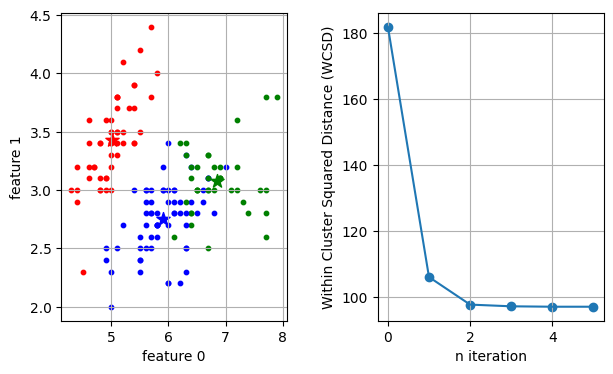

In [6]:
color_dict = dict({0: "red", 1: "blue", 2: "green"})
colors_points = [color_dict[ass] for ass in list(results.assignments)]
fig, axs = plt.subplots(figsize = (7,4), nrows = 1, ncols = 2)

axs = axs.flatten()
for point in range(data_numpy.data.shape[0]):
    axs[0].scatter(data_numpy.data[point, 0], data_numpy.data[point, 1], color = colors_points[point], s = 10)

for i in range(3):
    axs[0].scatter(results.final_centroids[i, 0], results.final_centroids[i, 1], color = color_dict[i], marker = "*", s = 100)
axs[0].set_xlabel("feature 0")
axs[0].set_ylabel("feature 1")
axs[0].grid()

axs[1].scatter(np.arange(0, len(results.loss)), results.loss)
axs[1].plot(np.arange(0, len(results.loss)), results.loss)
axs[1].set_xlabel("n iteration")
axs[1].set_ylabel("Within Cluster Squared Distance (WCSD)")
axs[1].grid()

plt.subplots_adjust(wspace = 0.4)

### Serial kmeans - minor optimizations 

Now I optimize the previous first attempt, in order to have an more efficient code as a starting point, before parallelization.


Suggestions for optimization - from chatGPT:

1. Replaced centroid initialization with a vectorized selection: no need to use vstack and a for loop!
2. Vectorized the distance computation step for clarity and performance: no need to allocate a matrix for distances!
3. Optimized centroid updates and distance summing: use broadcasting!


4. Avoid recomputing norms where possible: compute the wcsd BEFORE updating the centroids, and then once at the exit of the loop.
5. Early exit if any cluster has no points (add checks).
6. Improve WCSD calculation by vectorizing it fully.


A new trick:

```{python}
distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
```

this is **broadcasting** in 3 dimensions. Look at the schema PROVE/shcemino_broadcasting.jpeg

In [ ]:
X = data_numpy.data
centroids = np.array([[1,1,1,1], [2,2,2,2], [3,3,3,3]])

N, D = X.shape
k = centroids.shape[0]

a = centroids[np.newaxis, :, :] # -> shape (1, k, D)
b = X[:, np.newaxis, :] # -> shape (N, 1, D)

c = a - b # -> shape (N, k, D)
c.shape 

# this is equivalent to
d = np.zeros(shape = (N, k, D))
for i in range(N):
    for j in range(k):
        for l in range(D):
            d[i, j, l] = centroids[j, l] - X[i, l]

np.all(c == d)


a = np.array([1,2,3,4])
b = np.array([1,1,1,1])
mask = (a==b)
a[mask]
len(mask)
type(mask)

matrix = np.array([[1,2,3],[4,5, 6]])

e = matrix[np.arange(2), [1, 2]]
e

True

In [11]:
from dataclasses import dataclass # for clear outputs in the form of a class

@dataclass
class KMeansResult:
    assignments: np.ndarray
    final_centroids: np.ndarray
    loss: list

def serial_k_means_optimized(k: int, X: np.ndarray, n_iter_max: int, seed: int, verbose = False):
    """
    Most basic version of k means, with random centroid initialization (Forgy).
    k: number of clusters
    X: data matrix with nrows = number of points, ncols = number of features
    n_max: maximum number of iterations

    The algorithm stops when either the assignations of the points do not change anymore,
    or n_max is reached.
    """
    np.random.seed(seed)
    num_points, _ = X.shape
    assignments = np.zeros(shape = (num_points, ), dtype = int)
    WCSD_list = []
    """
    Centroid initialization
    """
    idxs = np.random.choice(np.arange(0, num_points), size = k, replace = False)
    centroids = X[idxs, :].copy() ## OPTIMIZATION 1.

    for n in range(n_iter_max):
        old_assignments = assignments.copy()
        """
        Compute current distances and update point assignments accordingly
        """
        # distances is (N, k)
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2) # OPTIMIZATION 2.
        wcsd = np.sum(distances[np.arange(len(assignments)), assignments])
        WCSD_list.append(wcsd)
        # Update assignments
        assignments = np.argmin(distances, axis=1)
        if np.all(old_assignments == assignments):
            if verbose:
                print(f"Algorithm converged at iteration {n}/{n_iter_max}")
            break
        """
        Update centroids
        """
        for centroid_idx in range(k):
            # OPTIMIZATION 3 :one less "for loop"
            # OPTIMIZATION 4: use np.mean directly
            centroids[centroid_idx, :] = np.mean(X[(assignments == centroid_idx), :], axis = 0)
    """
    Compute final loss
    """
    final_distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    wcsd = np.sum(final_distances[np.arange(len(assignments)), assignments])
    WCSD_list.append(wcsd)
    results = KMeansResult(assignments, centroids, WCSD_list)
    if n == n_iter_max and verbose:
        print(f"Algorithm did not converge in {n_iter_max} iterations.")
    return results

results = serial_k_means_optimized(k = 3, X = data_numpy.data, n_iter_max = 10, seed = 1234)

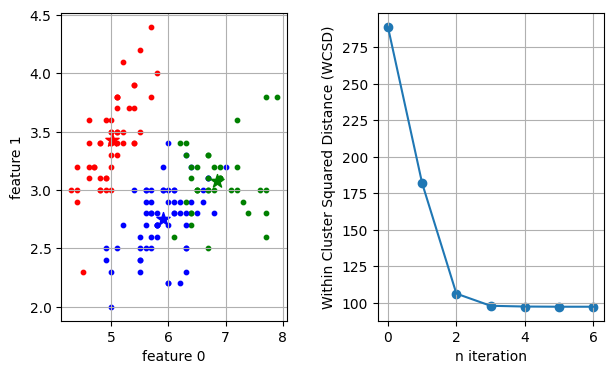

In [12]:
color_dict = dict({0: "red", 1: "blue", 2: "green"})
colors_points = [color_dict[ass] for ass in list(results.assignments)]
fig, axs = plt.subplots(figsize = (7,4), nrows = 1, ncols = 2)

axs = axs.flatten()
for point in range(data_numpy.data.shape[0]):
    axs[0].scatter(data_numpy.data[point, 0], data_numpy.data[point, 1], color = colors_points[point], s = 10)

for i in range(3):
    axs[0].scatter(results.final_centroids[i, 0], results.final_centroids[i, 1], color = color_dict[i], marker = "*", s = 100)
axs[0].set_xlabel("feature 0")
axs[0].set_ylabel("feature 1")
axs[0].grid()

axs[1].scatter(np.arange(0, len(results.loss)), results.loss)
axs[1].plot(np.arange(0, len(results.loss)), results.loss)
axs[1].set_xlabel("n iteration")
axs[1].set_ylabel("Within Cluster Squared Distance (WCSD)")
axs[1].grid()

plt.subplots_adjust(wspace = 0.4)

### Profiling the two versions

Lets see if the optimizations implemented really make a difference.

In [10]:
%timeit serial_k_means(k=3, X=data_numpy.data, n_iter_max=10, seed=1234)  # old version
%timeit serial_k_means_optimized(k=3, X=data_numpy.data, n_iter_max=10, seed=1234)  # new version

6.3 ms ± 96.3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
238 µs ± 1.79 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


More or less we have a 10x speedup - nice! Now lets move forward and parallelize.

# Step 2: a parallel version of kmeans

I have 8 cores on my machine, so I will define 8 processes. I will divide the dataset in 8 chuncks and compute the distances from the centroids independently. 

Since the algorithmic complexity of kmeans is

$$\mathcal{O}(N \cdot k \cdot D \cdot n_{\text{iter}})$$

and I divide the data in $8$ chuncks, I expect to find - approximately - that the time taken by the parallel version is $1/8$ of the time taken by the serial version.

**ATTENTION** The code below cannot run within a Jupiter notebook. Its is here just for reference, but you need to run it from the script kmeans_parallel.py